# Importing Libraries

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
import string
import re

from wordcloud import WordCloud

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.model_selection import RandomizedSearchCV

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Extracting Data from Zipfile

In [2]:
zip_path = '/content/movie.csv.zip'  # Path to your ZIP file
extract_path = '/content'  # Destination folder

# Create extraction directory if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Files extracted to: /content


# Loading Dataset and checking basic structure

In [3]:
df = pd.read_csv('/content/movie.csv')

In [4]:
df.shape

(40000, 2)

In [5]:
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [6]:
df['label'].isna().sum()

0

In [7]:
df['label'].value_counts()

,count
label,
0,20019
1,19981


# 0 - Negative
#1 - Positive

In [8]:
# checking for duplicate instances
no_of_duplicates=df.duplicated().sum()
no_of_duplicates

277

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(39723, 2)

In [11]:
df['label'].value_counts()

,count
label,
1,19908
0,19815


In [12]:
df.rename(columns={'text':'Movie Review', 'label':'Sentiment'}, inplace=True)

In [13]:
df.head()

,Movie Review,Sentiment
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


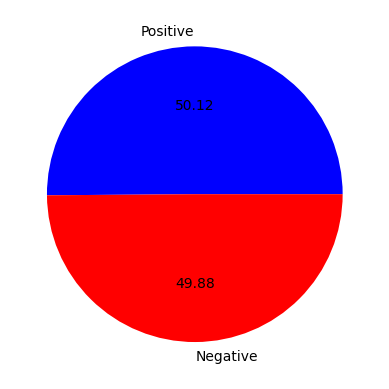

In [14]:
plt.pie(df['Sentiment'].value_counts(), labels=['Positive', 'Negative'], autopct="%0.2f", colors=['blue', 'red'])
plt.show()

# Finding and Visualizing No. of characters, words, sentences in each movie review group by their sentiments.

In [15]:
df['txt_characters'] = df['Movie Review'].apply(len)
df['txt_words'] = df['Movie Review'].apply(lambda x:len(nltk.word_tokenize(x)))
df['txt_sentences'] = df['Movie Review'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [16]:
df.head()

,Movie Review,Sentiment,txt_characters,txt_words,txt_sentences
0,I grew up (b. 1965) watching and loving the Th...,0,874,174,17
1,"When I put this movie in my DVD player, and sa...",0,1811,393,14
2,Why do people who do not know what a particula...,0,983,205,9
3,Even though I have great interest in Biblical ...,0,351,76,5
4,Im a die hard Dads Army fan and nothing will e...,1,983,223,9


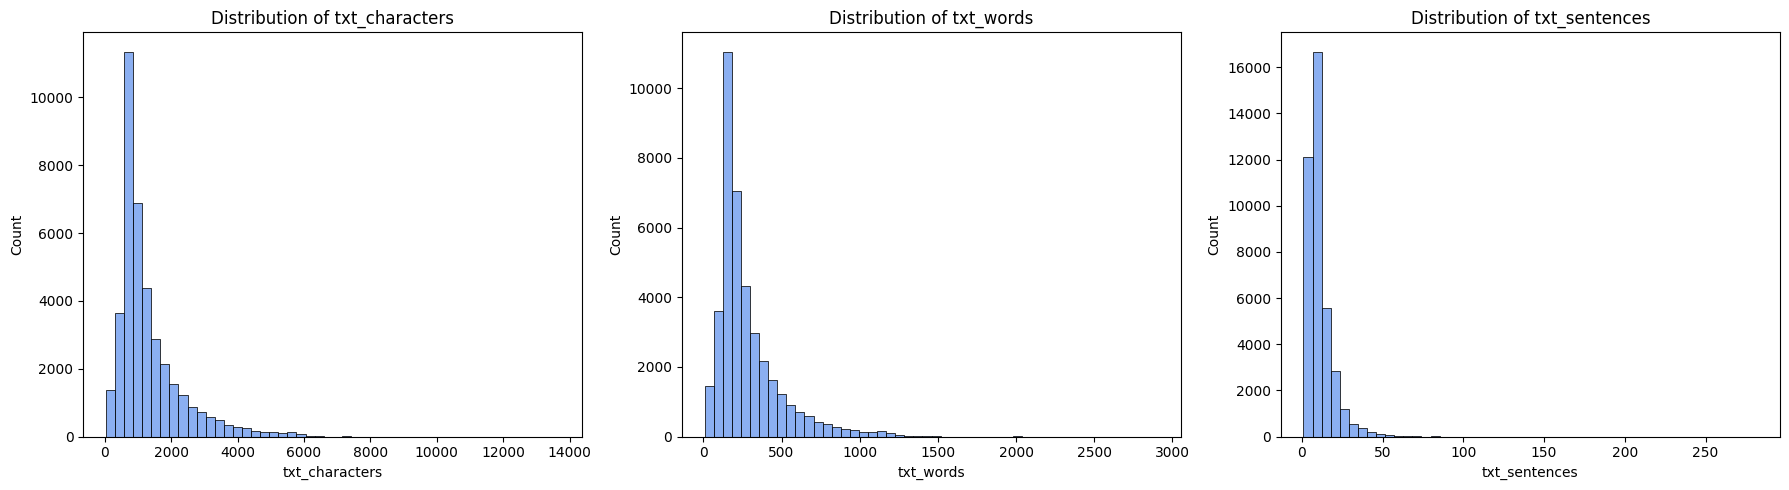

In [17]:
numerical_feature_cols=['txt_characters', 'txt_words', 'txt_sentences']
plt.figure(figsize=(18, 5))
for i,col in enumerate(numerical_feature_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(data=df,x=col,bins=50,color='#6495ED')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

We can conclude that the dataset is right skewed and contains outliers too from above Histogram Graph.

In [18]:
df[['txt_characters', 'txt_words', 'txt_sentences']].describe()

,txt_characters,txt_words,txt_sentences
count,39723.000000,39723.000000,39723.000000
mean,1311.169197,279.853007,10.749943
std,989.292967,207.834197,7.884767
min,32.000000,8.000000,1.000000
25%,698.000000,151.000000,6.000000
50%,973.000000,209.000000,9.000000
75%,1597.000000,341.000000,13.000000
max,13704.000000,2911.000000,282.000000


In [19]:
df[df['Sentiment'] == 0][['txt_characters', 'txt_words', 'txt_sentences']].describe()

,txt_characters,txt_words,txt_sentences
count,19815.000000,19815.000000,19815.000000
mean,1293.136008,278.418319,11.030482
std,943.039706,200.662716,7.933577
min,32.000000,8.000000,1.000000
25%,705.000000,153.000000,6.000000
50%,973.000000,211.000000,9.000000
75%,1571.000000,338.000000,13.000000
max,8969.000000,1936.000000,118.000000


In [20]:
df[df['Sentiment'] == 1][['txt_characters', 'txt_words', 'txt_sentences']].describe()

,txt_characters,txt_words,txt_sentences
count,19908.000000,19908.000000,19908.000000
mean,1329.118143,281.280993,10.470715
std,1032.987419,214.730011,7.826104
min,65.000000,14.000000,1.000000
25%,691.000000,148.000000,6.000000
50%,973.000000,208.000000,9.000000
75%,1622.000000,344.000000,13.000000
max,13704.000000,2911.000000,282.000000


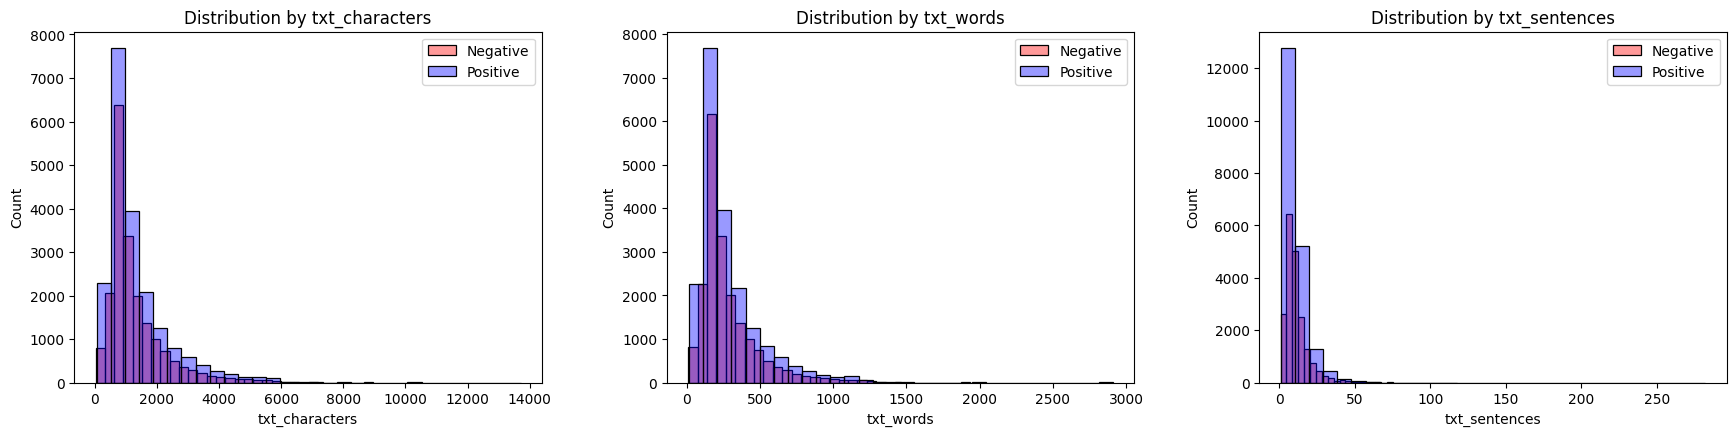

In [21]:
numerical_feature_cols=['txt_characters', 'txt_words', 'txt_sentences']
plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_feature_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[df['Sentiment'] == 0][col], color='red', alpha=0.4, label='Negative', bins=30)
    sns.histplot(df[df['Sentiment'] == 1][col], color='blue', alpha=0.4, label='Positive', bins=30)
    plt.title(f'Distribution by {col}')
    plt.legend(loc='upper right')

plt.tight_layout(pad=3)
plt.show()

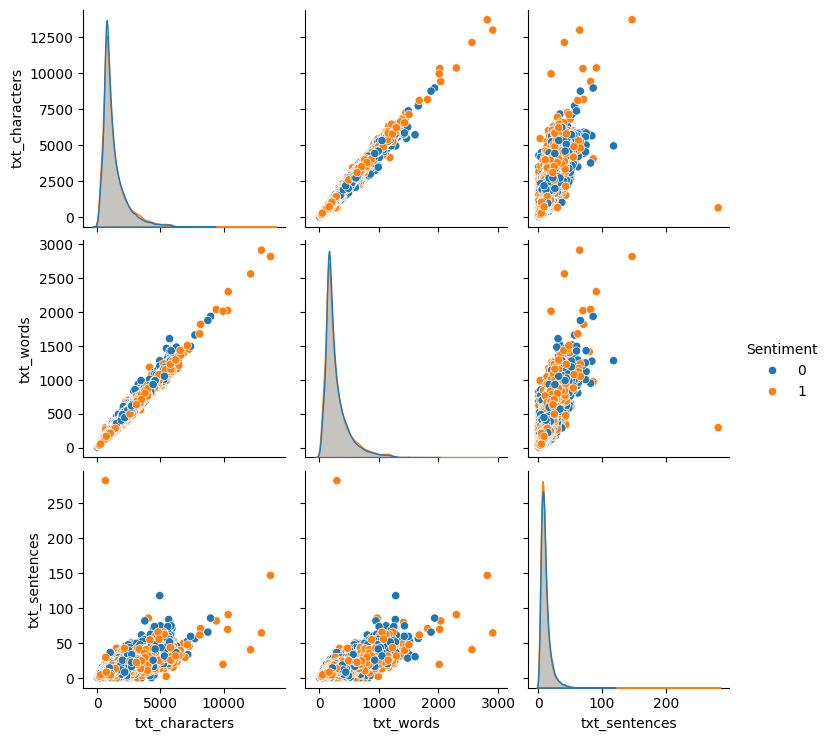

In [22]:
sns.pairplot(df, hue='Sentiment')

<Axes: >

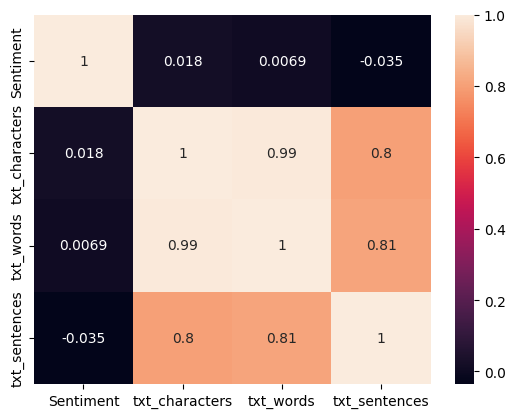

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Moview Review before processing text using nltk

In [24]:
print(df['Movie Review'][100])
print(df['Sentiment'][100])

In the history of cinema, every great film-maker had to create a first film. Many times when viewed after they have become a success, a light bulb goes on in our heads. The connection is made and we see the solid foundation from where they started. So it is with HORSES ON MARS. It is the subtle humor woven around a seemingly straight-forward narrative that tells a great story, but allows you to enjoy the visuals at the same time. In the imagery, I found great attention to detail and a production polish that is rare in any student film.<br /><br />A young film-maker always has improvements to be made. But if Mr. Anderson continues on this path, I think we will someday look back on this film as the beginning a great career.<br /><br />You should definitely view this film. Nothing beats the grandeur of the big screen.
1


# Data Preprocessing

In [25]:
stopwords_set = set(stopwords.words('english'))

def transform_text(text):
    # Remove HTML tags
    text = re.sub('<[^>]*>', '', text)

    # Remove emojis
    text = re.sub('(?::|;|=)(?:-)?(?:\)|\(|D|P)', '', text)

    # Replace non-word characters (punctuation) with spaces and convert text to lowercase
    text = re.sub('[\W+]', ' ', text.lower())

    # Tokenize the text using nltk.word_tokenize for proper tokenization
    tokens = nltk.word_tokenize(text)

    # Initialize the stemmer
    prter = PorterStemmer()

    # Stem tokens and remove stopwords
    text = [prter.stem(word) for word in tokens if word not in stopwords_set]

    return " ".join(text)

In [26]:
df['transformed_review'] = df['Movie Review'].apply(transform_text)

Sample test of transfrom_text function

In [27]:
transform_text('this is my tags <h1> :) <p>helo world<p> <div> <div> </h2> , <html>Cool! :D I am running fast! :-)</html>')

'tag helo world cool run fast'

Moview Review After processing text using nltk

In [28]:
print(df['transformed_review'][100])
print(df['Sentiment'][100])

histori cinema everi great film maker creat first film mani time view becom success light bulb goe head connect made see solid foundat start hors mar subtl humor woven around seemingli straight forward narr tell great stori allow enjoy visual time imageri found great attent detail product polish rare student film young film maker alway improv made mr anderson continu path think someday look back film begin great career definit view film noth beat grandeur big screen
1


Visualizing WordCloud

In [29]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

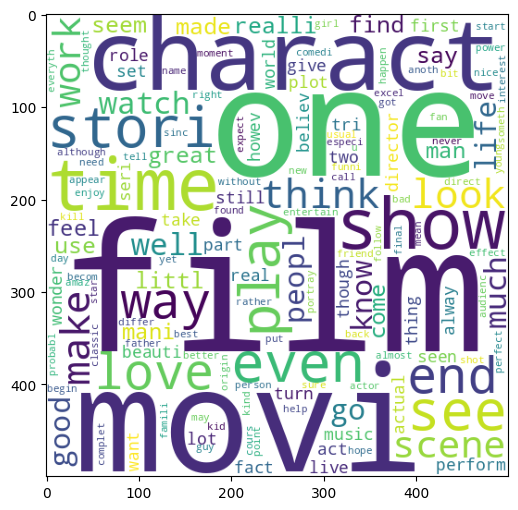

In [30]:
pos_wc = wc.generate(df[df['Sentiment'] == 1]['transformed_review'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(pos_wc)

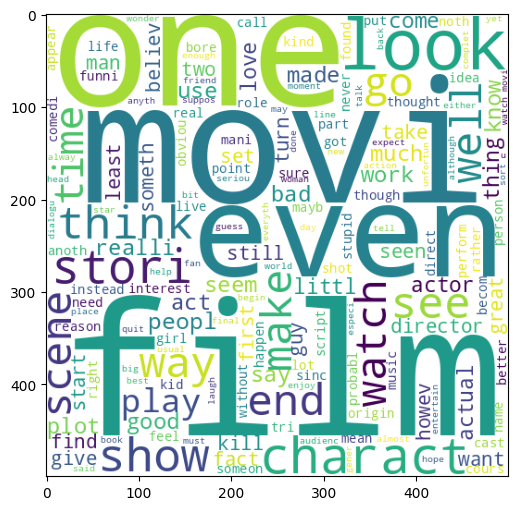

In [31]:
neg_wc = wc.generate(df[df['Sentiment'] == 0]['transformed_review'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(neg_wc)

Corpus

In [32]:
pos_corpus = []
for msg in df[df['Sentiment'] == 1]['transformed_review'].tolist():
    for word in msg.split():
        pos_corpus.append(word)

In [33]:
len(pos_corpus)

2422319

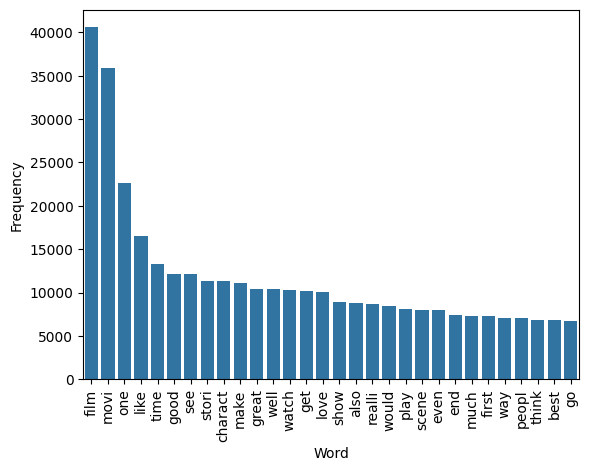

In [34]:
word_counts = pd.DataFrame(Counter(pos_corpus).most_common(30), columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=word_counts)

plt.xticks(rotation='vertical')
plt.show()

In [35]:
neg_corpus = []
for msg in df[df['Sentiment'] == 0]['transformed_review'].tolist():
    for word in msg.split():
        neg_corpus.append(word)

In [36]:
len(neg_corpus)

2333351

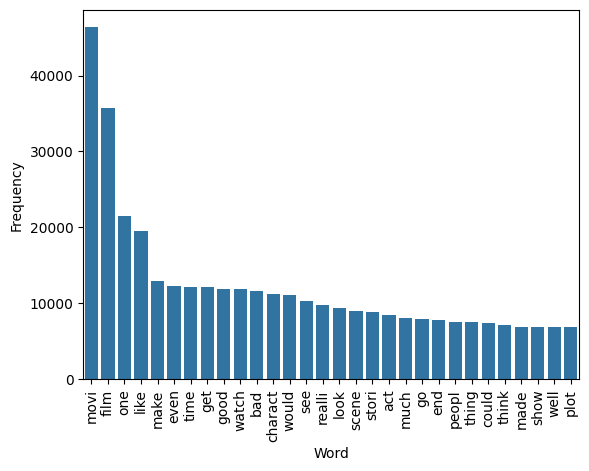

In [37]:
word_counts = pd.DataFrame(Counter(neg_corpus).most_common(30), columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=word_counts)

plt.xticks(rotation='vertical')
plt.show()

In [38]:
tot_corpus = []
for msg in df['transformed_review'].tolist():
    for word in msg.split():
        tot_corpus.append(word)

In [39]:
len(tot_corpus)

4755670

# Data Processing

In [75]:
tfidf = TfidfVectorizer(max_features = 3000)
X = tfidf.fit_transform(df['transformed_review']).toarray()

In [76]:
X.shape

(39723, 3000)

In [77]:
y = df['Sentiment'].values

Train-Test Split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

All models object that will be used for review classification

In [79]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=30,random_state=2)
xgb = XGBClassifier(n_estimators=30,random_state=2)

In [80]:
voting = VotingClassifier(
    estimators=[
        ('lr', lrc),
        ('etc', etc),
        ('rfc', rfc),
        ('bnb', bnb)
    ],
    voting='soft',
    weights=[3, 2, 2, 1]  # Higher weights for better models
)

In [81]:
base_learners = [
    ('lr', lrc),
    ('etc', etc),
    ('bnb', bnb),
    ('rfc', rfc)
]

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression()
)

Classifier model dictionary and function to get accuracy and precision across all models

In [82]:
clfs = {
    'GNB': gnb,
    'MNB': mnb,
    'BNB' : bnb,
    'KN' : knc,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb,
    'voting':voting,
    'stacking':stack_clf
}

In [83]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [49]:
#Checking using max_features = [3000, 5000, 7000]

accuracy_3000 = []
precision_3000 = []

accuracy_5000 = []
precision_5000 = []

accuracy_7000 = []
precision_7000 = []

In [72]:
for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    accuracy_3000.append(current_accuracy)
    precision_3000.append(current_precision)

Checking performance across all models for all max_features values

In [51]:
performance_df_3000 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_3000,'Precision':precision_3000}).sort_values('Precision',ascending=False)

performance_df_3000

,Algorithm,Accuracy,Precision
12,stacking,0.882945,0.871630
11,voting,0.879799,0.866634
5,LR,0.878918,0.865503
8,ETC,0.850346,0.851691
2,BNB,0.841913,0.840234
1,MNB,0.847325,0.833578
6,RF,0.829956,0.828252
0,GNB,0.802517,0.806636
10,xgb,0.822656,0.794680
7,AdaBoost,0.769918,0.726705


In [62]:
performance_df_5000 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_5000,'Precision':precision_5000}).sort_values('Precision',ascending=False)

performance_df_5000

,Algorithm,Accuracy,Precision
12,stacking,0.883197,0.872246
11,voting,0.880554,0.868097
5,LR,0.879043,0.865716
8,ETC,0.859283,0.861803
2,BNB,0.843801,0.848422
1,MNB,0.848458,0.840100
6,RF,0.838263,0.838010
10,xgb,0.818880,0.790503
0,GNB,0.782882,0.787910
7,AdaBoost,0.768030,0.738269


In [73]:
performance_df_7000 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_7000,'Precision':precision_7000}).sort_values('Precision',ascending=False)

performance_df_7000

,Algorithm,Accuracy,Precision
12,stacking,0.884833,0.873762
11,voting,0.883323,0.871358
5,LR,0.879547,0.865848
8,ETC,0.851227,0.855043
2,BNB,0.844179,0.854588
1,MNB,0.851227,0.847163
6,RF,0.837130,0.839722
10,xgb,0.821523,0.791522
0,GNB,0.773191,0.787389
7,AdaBoost,0.766016,0.731593


We can see there is not much difference in accuracy and precision so choosing max_features = 3000 for less computation with almost same values of accuracy and precision.

In [96]:
# Hyper-Tuning top 4 performing models to increase performance and applying voting and stacking to these
# Logistic Regression
# Extra Trees Classifier
# Random Forest
# BernoulliNB

In [86]:
# BernoulliNB
bnb = BernoulliNB()
bnb_params = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],  # Smoothing parameter
    'binarize': [0.0, 0.5, 1.0]  # Threshold for binarizing features
}

bnb_random = RandomizedSearchCV(
    estimator=bnb,
    param_distributions=bnb_params,
    n_iter=10,
    cv=5,
    random_state=2,
    verbose=1,
    n_jobs=-1
)

bnb_random.fit(X_train, y_train)
print("Best Parameters for BernoulliNB:", bnb_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for BernoulliNB: {'binarize': 0.0, 'alpha': 2.0}


In [87]:
# Logistic Regression
lrc = LogisticRegression(solver='liblinear')
lrc_params = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Type of regularization
}

lrc_random = RandomizedSearchCV(
    estimator=lrc,
    param_distributions=lrc_params,
    n_iter=10,
    cv=5,
    random_state=2,
    verbose=1,
    n_jobs=-1
)

lrc_random.fit(X_train, y_train)
print("Best Parameters for Logistic Regression:", lrc_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Logistic Regression: {'penalty': 'l2', 'C': 1}


In [88]:
# Random Forest Classifier
rfc = RandomForestClassifier(random_state=2)
rfc_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_random = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=rfc_params,
    n_iter=15,
    cv=5,
    random_state=2,
    verbose=1,
    n_jobs=-1
)

rfc_random.fit(X_train, y_train)
print("Best Parameters for Random Forest:", rfc_random.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [89]:
# Extra Trees Classifier
etc = ExtraTreesClassifier(random_state=2)
etc_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

etc_random = RandomizedSearchCV(
    estimator=etc,
    param_distributions=etc_params,
    n_iter=15,
    cv=5,
    random_state=2,
    verbose=1,
    n_jobs=-1
)

etc_random.fit(X_train, y_train)
print("Best Parameters for Extra Trees:", etc_random.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters for Extra Trees: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


In [90]:
random_search_accuracy = []
random_search_precision = []

In [91]:
bnb_best = bnb_random.best_estimator_
lrc_best = lrc_random.best_estimator_
rfc_best = rfc_random.best_estimator_
etc_best = etc_random.best_estimator_

voting_best = VotingClassifier(
    estimators=[
        ('lr', lrc_best),
        ('etc', etc_best),
        ('rfc', rfc_best),
        ('bnb', bnb_best)
    ],
    voting='soft',
    weights=[3, 2, 2, 1]  # Higher weights for better models
)

base_learners = [
    ('lr', lrc_best),
    ('etc', etc_best),
    ('bnb', bnb_best),
    ('rfc', rfc_best)
]

stack_clf_best = StackingClassifier(
    estimators=base_learners,
    final_estimator=lrc_best
)

In [92]:
random_clfs = {
    'BNB_best' : bnb_best,
    'LR_best': lrc_best,
    'RF_best': rfc_best,
    'ETC_best': etc_best,
    'voting_best':voting_best,
    'stacking_best':stack_clf_best
}

In [93]:
def random_train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [94]:
for name,clf in random_clfs.items():

    current_accuracy,current_precision = random_train_classifier(clf, X_train,y_train,X_test,y_test)

    random_search_accuracy.append(current_accuracy)
    random_search_precision.append(current_precision)

In [95]:
random_search_performance_df = pd.DataFrame({'Algorithm':random_clfs.keys(),'Accuracy':random_search_accuracy,'Precision':random_search_precision}).sort_values('Precision',ascending=False)

random_search_performance_df

,Algorithm,Accuracy,Precision
5,stacking_best,0.882568,0.872457
1,LR_best,0.879043,0.865896
4,voting_best,0.876274,0.863368
3,ETC_best,0.862933,0.848946
0,BNB_best,0.842165,0.840661
2,RF_best,0.851982,0.835890


In [97]:
performance_df_3000

,Algorithm,Accuracy,Precision
12,stacking,0.882945,0.871630
11,voting,0.879799,0.866634
5,LR,0.878918,0.865503
8,ETC,0.850346,0.851691
2,BNB,0.841913,0.840234
1,MNB,0.847325,0.833578
6,RF,0.829956,0.828252
0,GNB,0.802517,0.806636
10,xgb,0.822656,0.794680
7,AdaBoost,0.769918,0.726705


Despite thorough hyperparameter tuning, the performance improvement was marginal. The accuracy and precision remained fairly consistent across models, indicating that the default parameters of certain models were already well-suited for the dataset.

In [103]:
# Stacking technique provide the best result both before and after hyper-tuning so using this as our main model for the sentiment analyser.

In [104]:
base_learners = [
    ('lr', LogisticRegression(solver='liblinear')),
    ('etc', ExtraTreesClassifier(n_estimators=50, random_state=2)),
    ('rfc', RandomForestClassifier(n_estimators=50, random_state=2)),
    ('bnb', BernoulliNB())
]

# Create Meta-model
meta_model = LogisticRegression(solver='liblinear')

# Create Stacking Classifier
main_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train the Main Model
main_model.fit(X_train, y_train)

# Make Predictions
y_pred_final = main_model.predict(X_test)

# Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Accuracy: 0.8823159219634991
Precision: 0.8716551040634292
Recall: 0.8940279542566709
F1 Score: 0.882699786726885


Importing the model

In [105]:
import joblib

# Save the TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf.pkl')
# Save the stacking model
joblib.dump(main_model, 'sentiment_model.pkl')

print("Model saved as 'sentiment_model.pkl & tfidf.pkl vectorizer'")

Model saved as 'sentiment_model.pkl & tfidf.pkl vectorizer'


Load the saved model

In [106]:
loaded_model = joblib.load('sentiment_model.pkl')
loaded_vectorizer = joblib.load('tfidf.pkl')

# Test loaded model by making predictions
y_pred_loaded = loaded_model.predict(X_test)

print("Accuracy after loading:", accuracy_score(y_test, y_pred_loaded))
print("Precision after loading:", precision_score(y_test, y_pred_loaded))
print("Recall after loading:", recall_score(y_test, y_pred_loaded))
print("F1 Score after loading:", f1_score(y_test, y_pred_loaded))

Accuracy after loading: 0.8823159219634991
Precision after loading: 0.8716551040634292
Recall after loading: 0.8940279542566709
F1 Score after loading: 0.882699786726885


# Prediction

In [120]:
def prediction(comment):
    preprocessed_comment = transform_text(comment)
    comment_list = [preprocessed_comment]
    comment_vector = loaded_vectorizer.transform(comment_list)
    prediction = loaded_model.predict(comment_vector)[0]
    return prediction



prediction = prediction(df['Movie Review'][35000])

if prediction == 1:
    print(f"positive comment and actual sentiment is {df['Sentiment'][35000]} ")
else:
    print(f"negative comment and actual sentiment is {df['Sentiment'][35000]} ")


positive comment and actual sentiment is 1 


1 - Positive

0 - Negative